In [1]:
!pip install ultralytics opencv-python tqdm pillow matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.7 MB/s eta 0:00:00


In [2]:

import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [ ]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/face-mask-detection")
print("Путь к датасету:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Путь к датасету: /kaggle/input/face-mask-detection


In [ ]:
import os

for f in os.listdir(path):
    print(f)

annotations
images


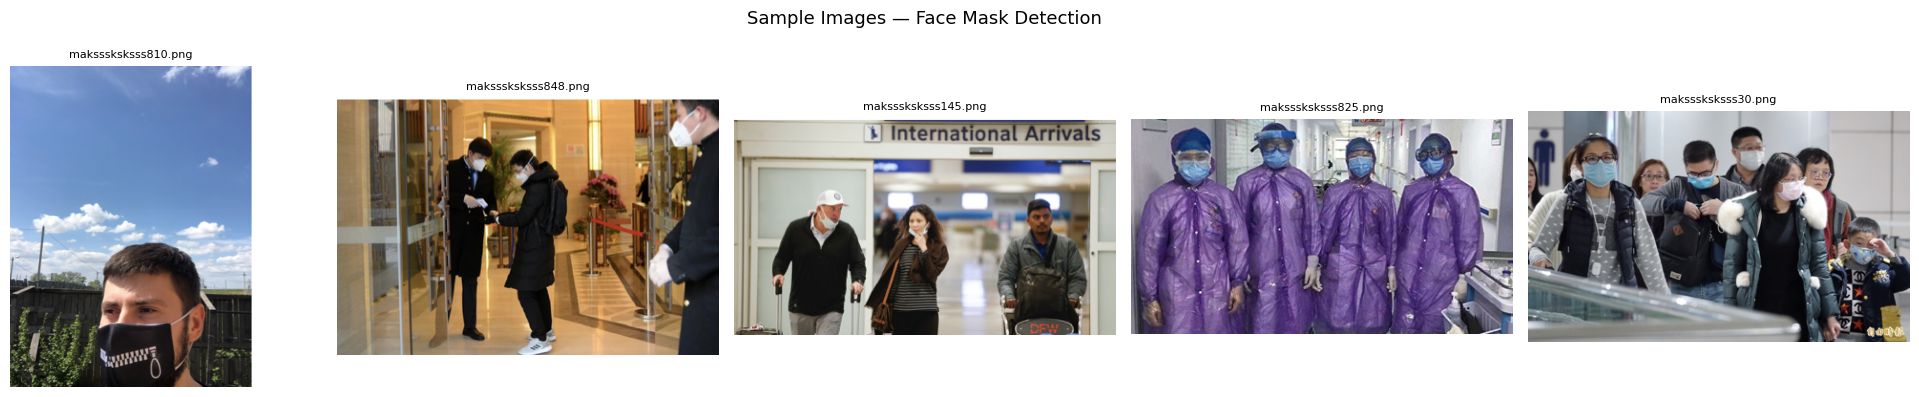

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

images_path = os.path.join(path, "images")
image_files = os.listdir(images_path)[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, fname in zip(axes, image_files):
    img = Image.open(os.path.join(images_path, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images — Face Mask Detection", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

INPUT_IMAGES      = os.path.join(path, "images")
INPUT_ANNOTATIONS = os.path.join(path, "annotations")
WORKING_DIR       = 'yolo_working'



In [7]:

dirs = ['images/train', 'images/val', 'labels/train', 'labels/val']

for d in dirs:
    os.makedirs(os.path.join(WORKING_DIR, d), exist_ok=True)


In [8]:

class_dict = {'with_mask': 0, 'mask_weared_incorrect': 1, 'without_mask': 2}

def convert_to_yolo_format(xml_file, img_width, img_height):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    yolo_data = []

    for obj in root.findall('object'):
        name = obj.find('name').text
        if name not in class_dict:
            continue

        label = class_dict[name]

        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_data.append(f"{label} {x_center} {y_center} {width} {height}")

    return yolo_data

In [9]:

image_files = [f for f in os.listdir(INPUT_IMAGES) if f.endswith('.png')]
train_files, val_files = train_test_split(image_files, test_size=0.2, random_state=42)

def process_files(files, split_type):
    print(f"Traitement de {len(files)} fichiers pour {split_type}...")

    for filename in tqdm(files):

        src_img_path = os.path.join(INPUT_IMAGES, filename)
        xml_filename = filename.replace('.png', '.xml')
        src_xml_path = os.path.join(INPUT_ANNOTATIONS, xml_filename)


        img = Image.open(src_img_path)
        w, h = img.size

        if os.path.exists(src_xml_path):
            yolo_annotations = convert_to_yolo_format(src_xml_path, w, h)

            dst_img_path = os.path.join(WORKING_DIR, 'images', split_type, filename)
            shutil.copy(src_img_path, dst_img_path)

            txt_filename = filename.replace('.png', '.txt')
            dst_label_path = os.path.join(WORKING_DIR, 'labels', split_type, txt_filename)

            with open(dst_label_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))


process_files(train_files, 'train')
process_files(val_files, 'val')

Traitement de 682 fichiers pour train...


100%|██████████| 682/682 [00:06<00:00, 107.97it/s]


Traitement de 171 fichiers pour val...


100%|██████████| 171/171 [00:01<00:00, 107.24it/s]


In [10]:
import os

yaml_content = f"""
train: {os.path.abspath(WORKING_DIR)}/images/train
val: {os.path.abspath(WORKING_DIR)}/images/val

nc: 3
names: ['with_mask', 'mask_weared_incorrect', 'without_mask']
"""

yaml_path = os.path.join(WORKING_DIR, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(yaml_content)



train: /content/yolo_working/images/train
val: /content/yolo_working/images/val

nc: 3
names: ['with_mask', 'mask_weared_incorrect', 'without_mask']



In [11]:
from ultralytics import YOLO
import os

model = YOLO('yolo11n.pt')

results = model.train(
    data=os.path.join(WORKING_DIR, 'dataset.yaml'),
    epochs=20,
    imgsz=640,
    batch=16,
    name='mask_model',
    project=os.path.join(WORKING_DIR, 'runs/detect')
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [12]:
import glob
found = glob.glob('/content/**/best.pt', recursive=True)
print(found)

['/content/runs/detect/yolo_working/runs/detect/mask_model/weights/best.pt']


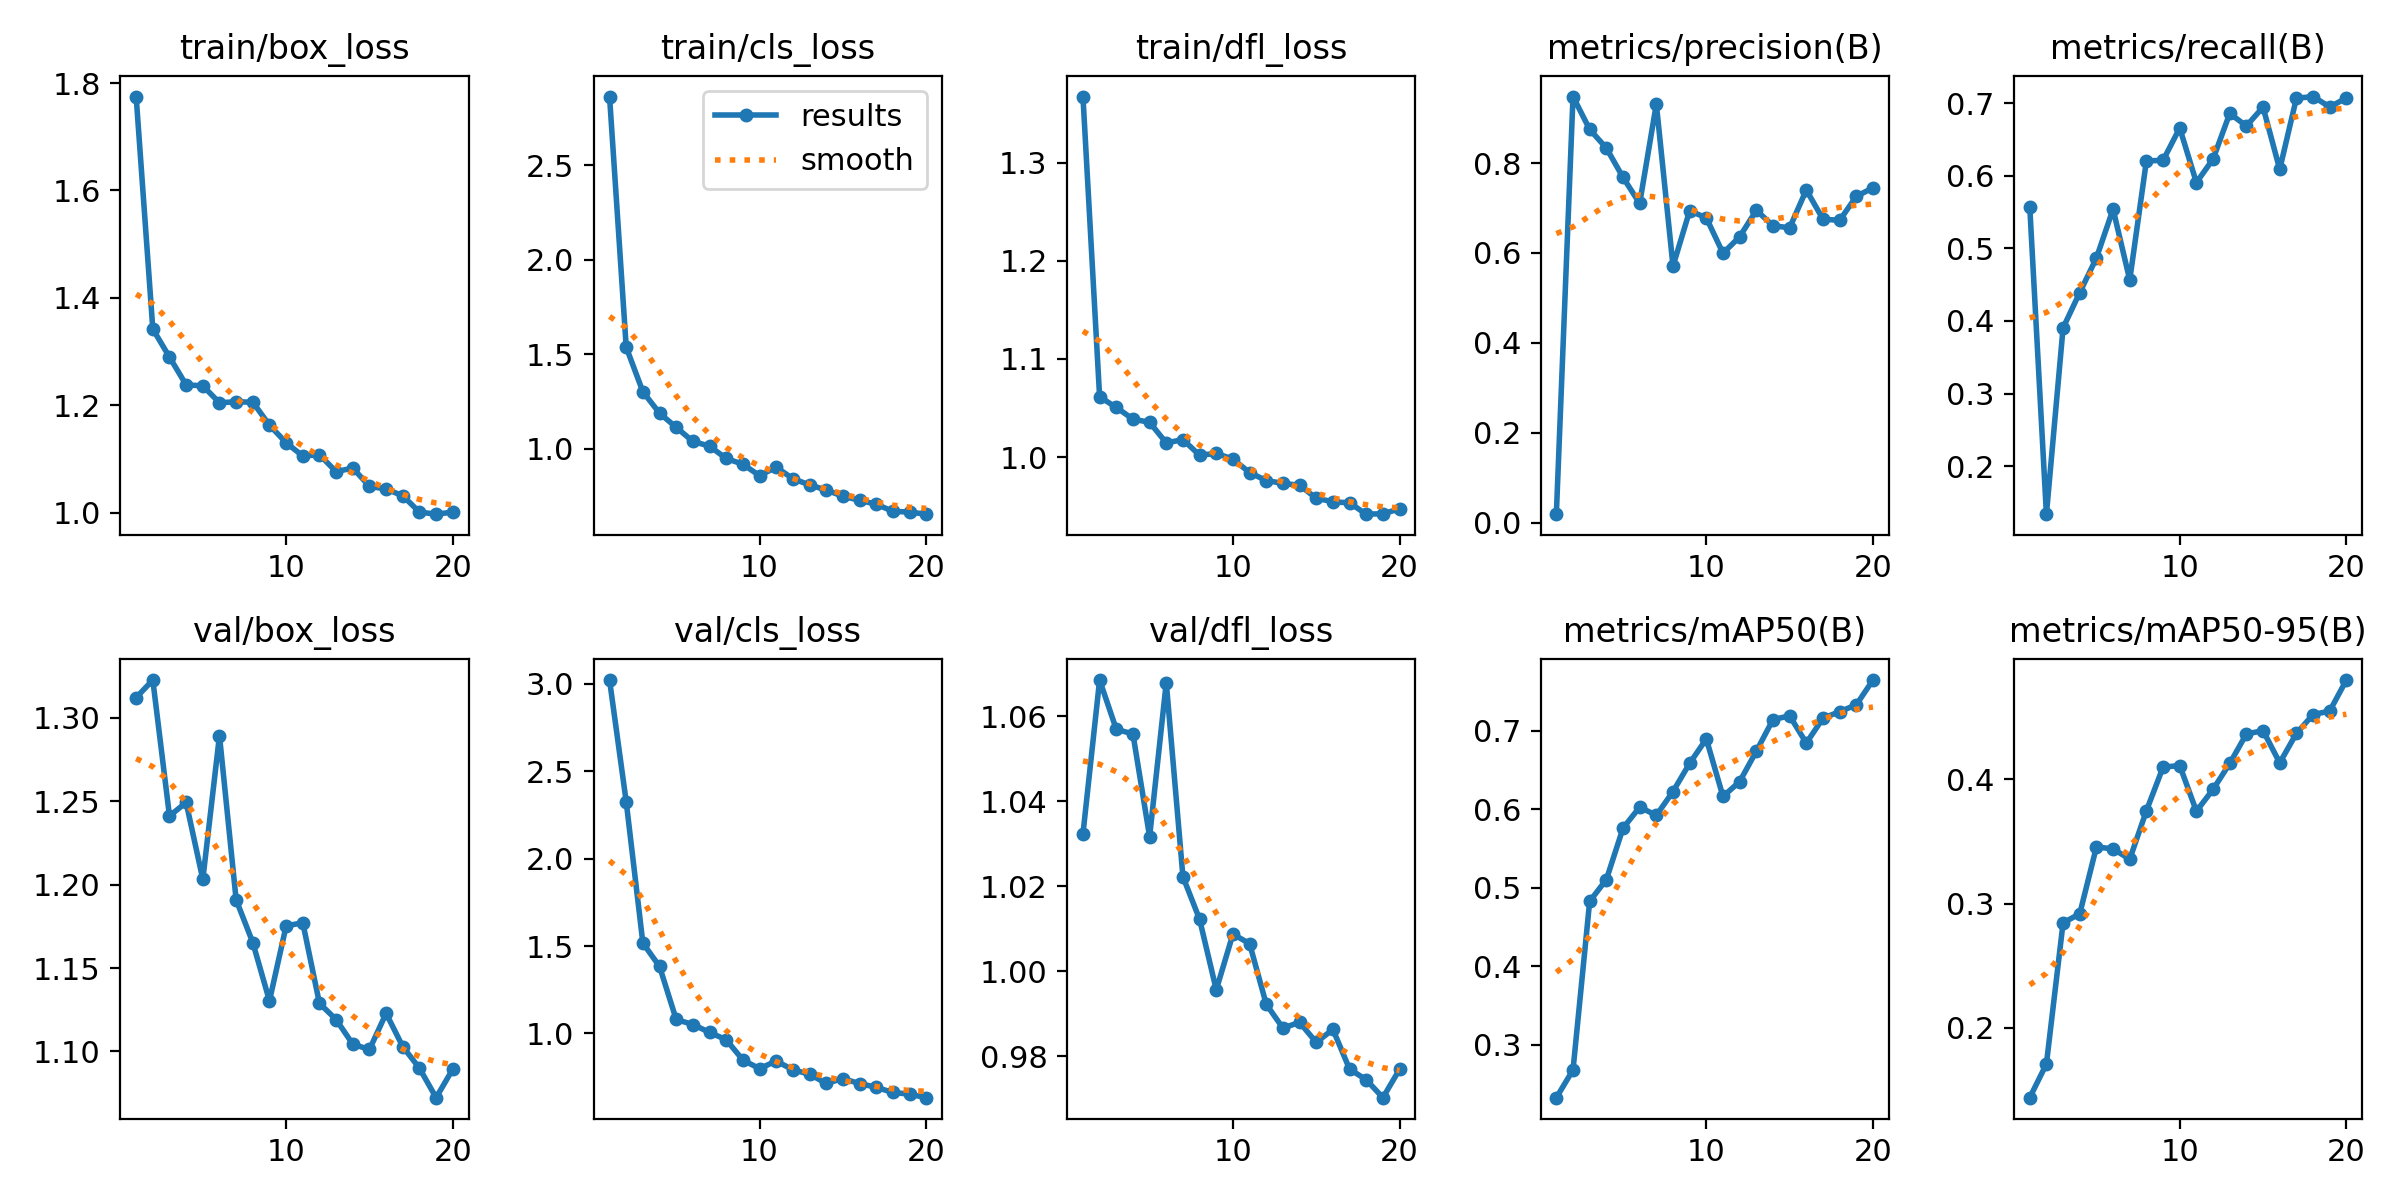

In [13]:
from IPython.display import Image as IPImage, display
import glob, os

results_candidates = glob.glob('/content/**/results.png', recursive=True)
if results_candidates:
    display(IPImage(results_candidates[0]))
else:
    print("results.png не найден")

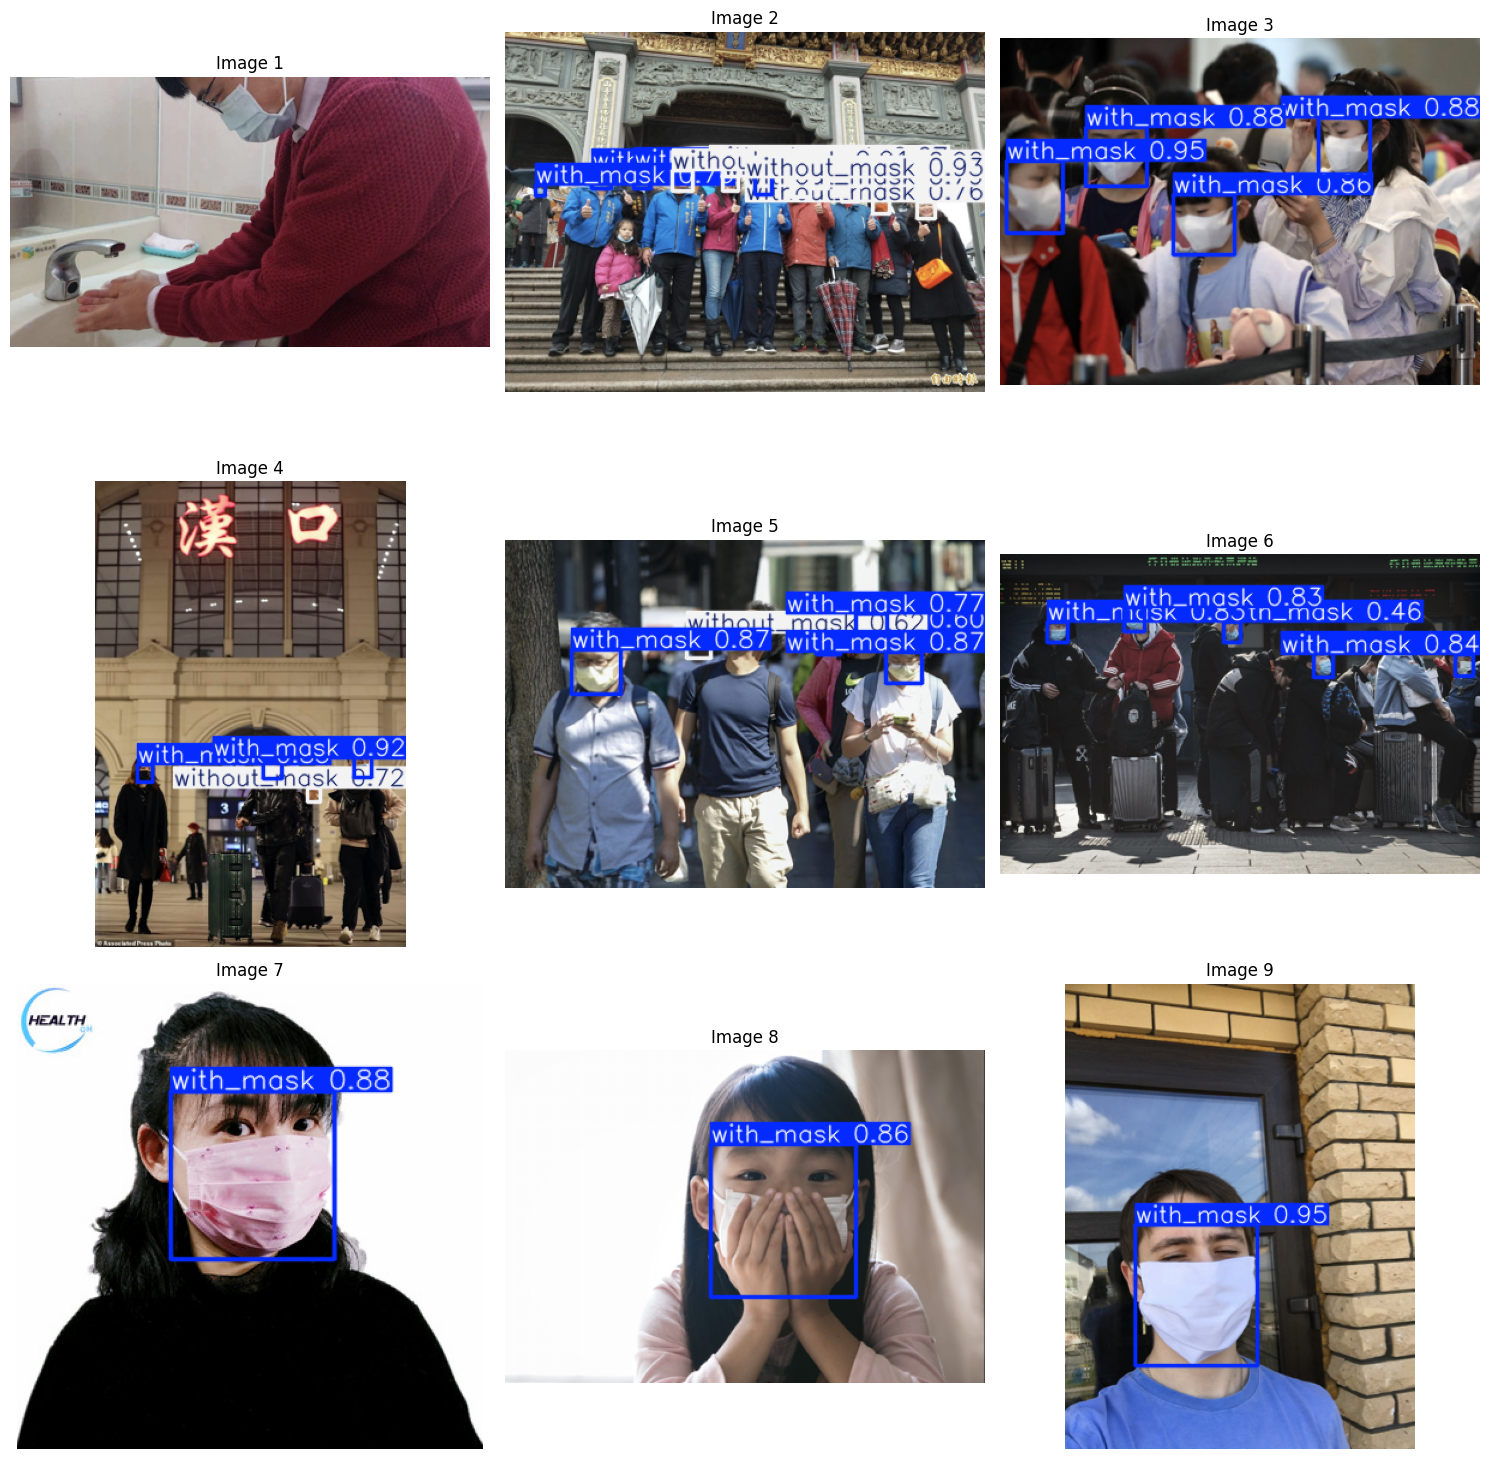

In [14]:
%matplotlib inline
import glob, os, math, cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

BEST_PT = found[0]
model_yolo = YOLO(BEST_PT)

val_images_dir = os.path.join(WORKING_DIR, 'images/val')
val_images = [os.path.join(val_images_dir, f)
              for f in os.listdir(val_images_dir)
              if f.endswith(('.png', '.jpg'))][:9]

all_predicted_images = []
for img_path in val_images:
    res = model_yolo.predict(img_path, conf=0.4, save=False, verbose=False)
    res_plotted = res[0].plot()
    all_predicted_images.append(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))

cols = 3
rows = math.ceil(len(all_predicted_images) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, img in enumerate(all_predicted_images):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}")

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

---
# 🔬 Часть 2 — Улучшенное обучение (Improved Training)

Ниже повторяется то же обучение, но с 5 улучшениями:

| # | Улучшение | Параметр | Зачем |
|---|-----------|----------|-------|
| 1 | **Mixup Augmentation** |  | Смешивает пары изображений → модель обобщает, не запоминает |
| 2 | **Copy-Paste Augmentation** |  | Вставляет объекты из одного фото в другое → больше разнообразия |
| 3 | **Cosine LR Scheduler** |  | Плавное затухание LR → лучшая сходимость на последних эпохах |
| 4 | **Label Smoothing** |  | Метки 0.05/0.95 вместо 0/1 → устойчивость к шумным аннотациям |
| 5 | **Early Stopping** |  | Стоп если val mAP не растёт 10 эпох → экономия времени, меньше оверфиттинга |


In [ ]:

from ultralytics import YOLO
import os

model_improved = YOLO('yolo11n.pt')  

results_improved = model_improved.train(
    data=os.path.join(WORKING_DIR, 'dataset.yaml'),
    epochs=20,
    imgsz=640,
    batch=16,
    name='mask_model_improved',
    project=os.path.join(WORKING_DIR, 'runs/detect'),

    mixup=0.1,

    copy_paste=0.1,

    cos_lr=True,

    label_smoothing=0.05,

    patience=10,
)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_model_improved, nbs=64, 

In [ ]:
import glob

found_improved = glob.glob(
    os.path.join(WORKING_DIR, 'runs/detect/mask_model_improved*/**/best.pt'),
    recursive=True
)

if not found_improved:
    found_improved = glob.glob('**/mask_model_improved*/**/best.pt', recursive=True)

print("Улучшенная модель:", found_improved)


Улучшенная модель: ['runs/detect/yolo_working/runs/detect/mask_model_improved/weights/best.pt']


## 📊 Сравнение: Baseline vs Improved

Сравниваем кривые обучения двух моделей рядом.


Baseline results: ['runs/detect/yolo_working/runs/detect/mask_model/results.png']
Improved results: ['runs/detect/yolo_working/runs/detect/mask_model_improved/results.png']


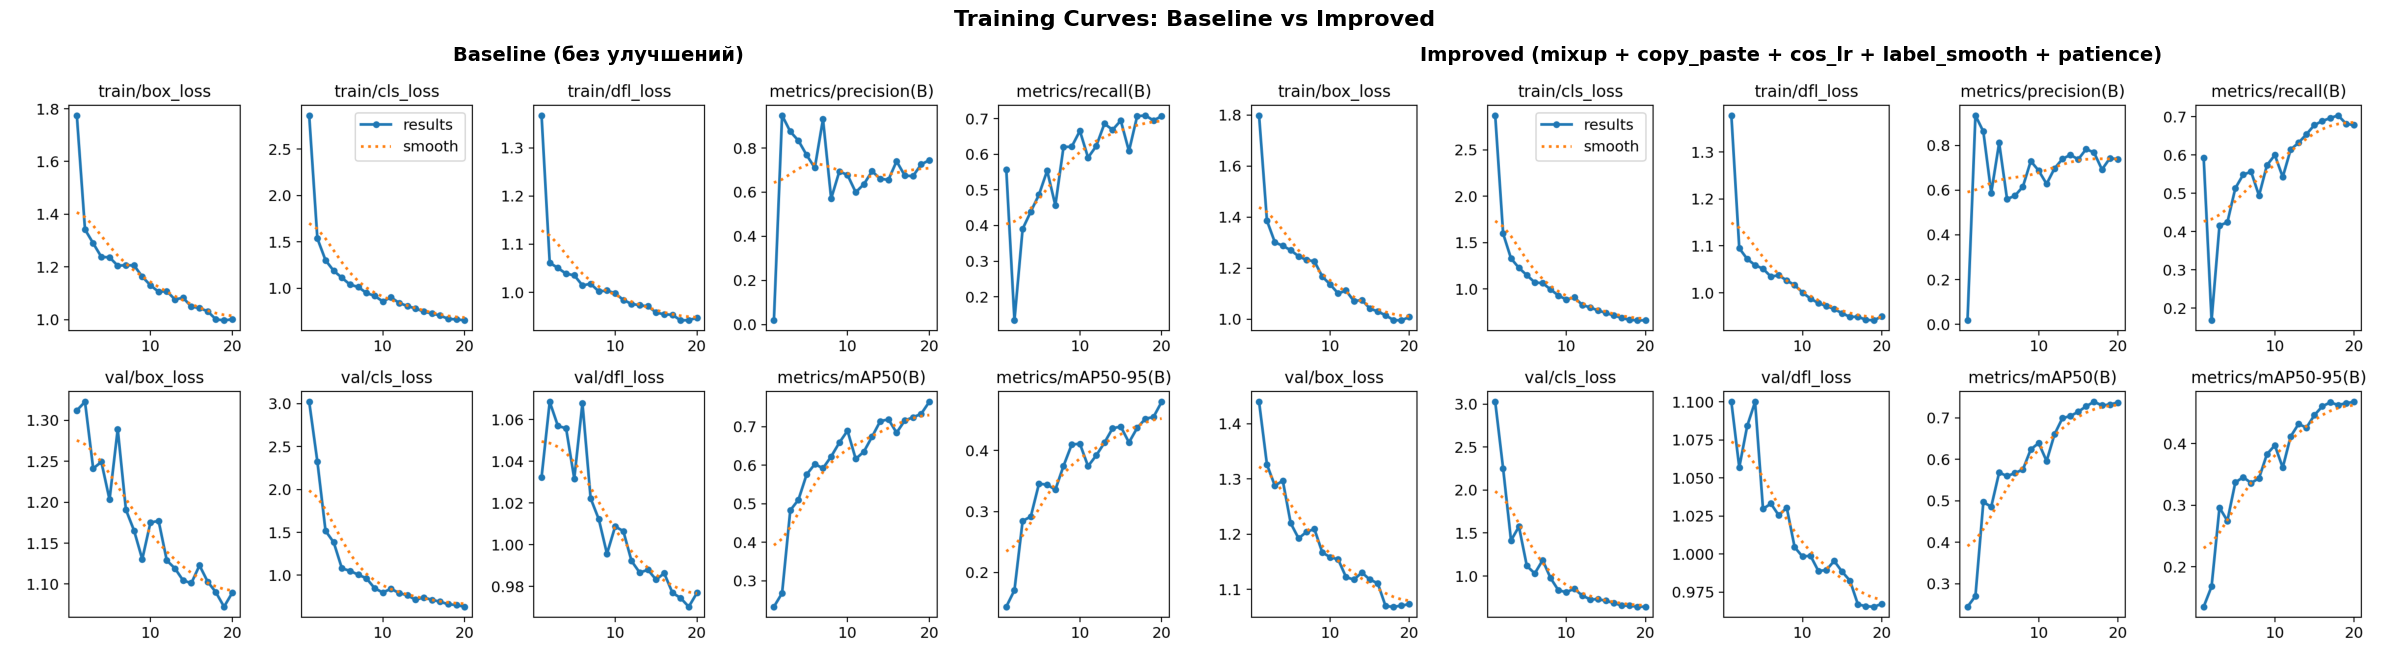

In [ ]:
import glob, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

baseline_results = glob.glob(
    os.path.join(WORKING_DIR, 'runs/detect/mask_model*', 'results.png')
)
baseline_results = [p for p in baseline_results if 'improved' not in p]

improved_results = glob.glob(
    os.path.join(WORKING_DIR, 'runs/detect/mask_model_improved*', 'results.png')
)

if not baseline_results:
    baseline_results = [p for p in glob.glob('**/results.png', recursive=True)
                        if 'improved' not in p]
if not improved_results:
    improved_results = [p for p in glob.glob('**/results.png', recursive=True)
                        if 'improved' in p]

print("Baseline results:", baseline_results)
print("Improved results:", improved_results)

fig, axes = plt.subplots(1, 2, figsize=(24, 7))

if baseline_results:
    img_b = mpimg.imread(baseline_results[0])
    axes[0].imshow(img_b)
    axes[0].set_title('Baseline (без улучшений)', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'results.png не найден (baseline)',
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Baseline', fontsize=14)
axes[0].axis('off')

if improved_results:
    img_i = mpimg.imread(improved_results[0])
    axes[1].imshow(img_i)
    axes[1].set_title('Improved (mixup + copy_paste + cos_lr + label_smooth + patience)',
                      fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'results.png не найден (improved)',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('Improved', fontsize=14)
axes[1].axis('off')

plt.suptitle('Training Curves: Baseline vs Improved', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Финальное сравнение метрик

Загружаем  обеих моделей и сравниваем лучший  и .


Baseline CSV: ['runs/detect/yolo_working/runs/detect/mask_model/results.csv']
Improved CSV: ['runs/detect/yolo_working/runs/detect/mask_model_improved/results.csv']
Колонки baseline: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


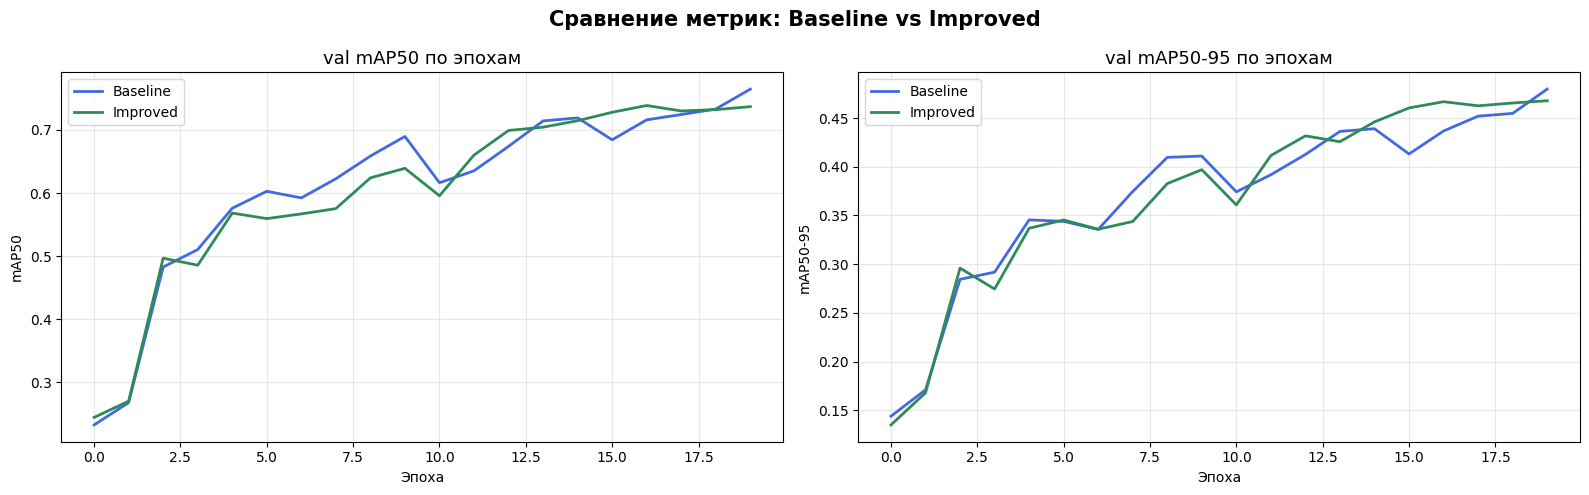

ИТОГОВАЯ ТАБЛИЦА (лучшие значения)
  Модель Best mAP50 Best mAP50-95 Эпох обучено
Baseline     0.7647        0.4798           20
Improved     0.7388        0.4678           20
Delta mAP50 = -0.0259 Baseline не хуже


In [ ]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt

baseline_csv = glob.glob(
    os.path.join(WORKING_DIR, 'runs/detect/mask_model*', 'results.csv')
)
baseline_csv = [p for p in baseline_csv if 'improved' not in p]

improved_csv = glob.glob(
    os.path.join(WORKING_DIR, 'runs/detect/mask_model_improved*', 'results.csv')
)

if not baseline_csv:
    baseline_csv = [p for p in glob.glob('**/results.csv', recursive=True)
                    if 'improved' not in p]
if not improved_csv:
    improved_csv = [p for p in glob.glob('**/results.csv', recursive=True)
                    if 'improved' in p]

print("Baseline CSV:", baseline_csv)
print("Improved CSV:", improved_csv)

if baseline_csv and improved_csv:
    df_b = pd.read_csv(baseline_csv[0])
    df_i = pd.read_csv(improved_csv[0])

    df_b.columns = df_b.columns.str.strip()
    df_i.columns = df_i.columns.str.strip()

    print("Колонки baseline:", list(df_b.columns))

    map50_col   = [c for c in df_b.columns if 'mAP50' in c and '95' not in c]
    map5095_col = [c for c in df_b.columns if 'mAP50-95' in c or 'mAP_50-95' in c]

    map50_col   = map50_col[0]   if map50_col   else None
    map5095_col = map5095_col[0] if map5095_col else None

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    if map50_col:
        axes[0].plot(df_b[map50_col].values, label='Baseline', color='royalblue', linewidth=2)
        axes[0].plot(df_i[map50_col].values, label='Improved', color='seagreen',  linewidth=2)
        axes[0].set_title('val mAP50 по эпохам', fontsize=13)
        axes[0].set_xlabel('Эпоха')
        axes[0].set_ylabel('mAP50')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

    if map5095_col:
        axes[1].plot(df_b[map5095_col].values, label='Baseline', color='royalblue', linewidth=2)
        axes[1].plot(df_i[map5095_col].values, label='Improved', color='seagreen',  linewidth=2)
        axes[1].set_title('val mAP50-95 по эпохам', fontsize=13)
        axes[1].set_xlabel('Эпоха')
        axes[1].set_ylabel('mAP50-95')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.suptitle('Сравнение метрик: Baseline vs Improved', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("ИТОГОВАЯ ТАБЛИЦА (лучшие значения)")
    print("=" * 50)

    summary = {}
    for label, df in [("Baseline", df_b), ("Improved", df_i)]:
        row = {"Модель": label}
        if map50_col:   row["Best mAP50"]    = round(df[map50_col].max(),   4)
        if map5095_col: row["Best mAP50-95"] = round(df[map5095_col].max(), 4)
        row["Эпох обучено"] = len(df)
        summary[label] = row

    summary_df = pd.DataFrame(summary).T.reset_index(drop=True)
    print(summary_df.to_string(index=False))

    if map50_col and "Baseline" in summary and "Improved" in summary:
        delta = summary["Improved"]["Best mAP50"] - summary["Baseline"]["Best mAP50"]
        sign  = "+" if delta >= 0 else ""
        print(f"Delta mAP50 = {sign}{delta:.4f}",
              "Improved лучше" if delta > 0 else "Baseline не хуже")

else:
    print("results.csv не найден для одной из моделей.")
    print("Убедитесь, что оба обучения завершились успешно.")

## 🖼️ Визуальное сравнение предсказаний

Одни и те же val-изображения прогоняем через обе модели и показываем рядом.


/tmp/ipykernel_1590/1693506136.py:45: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1590/1693506136.py:45: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1590/1693506136.py:45: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

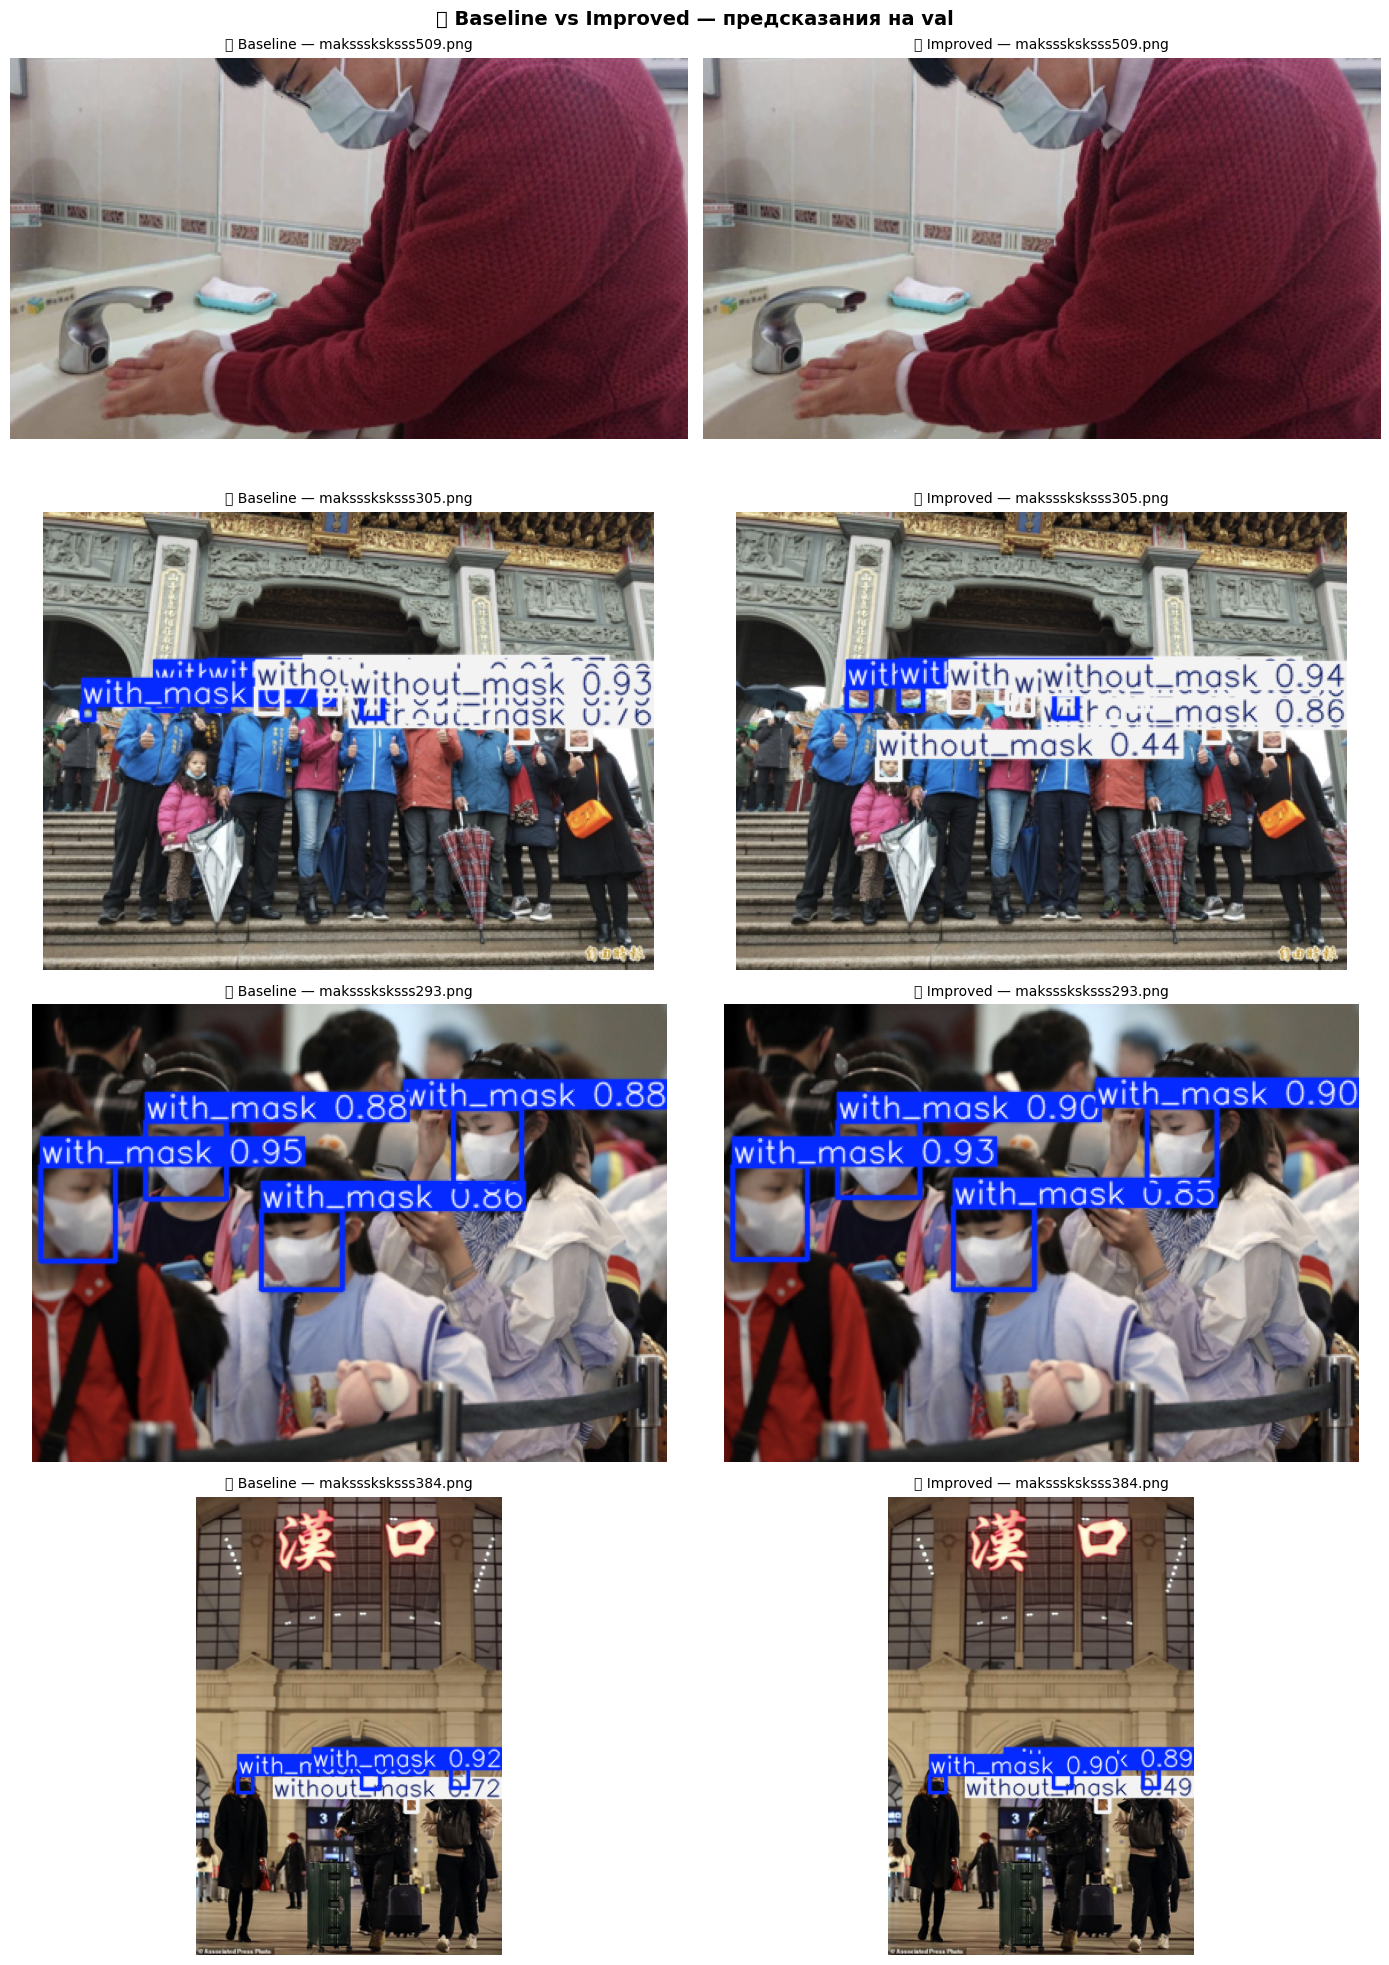

In [ ]:
import os, math, cv2, glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

BEST_PT_BASELINE = found[0] if found else None

BEST_PT_IMPROVED = found_improved[0] if found_improved else None

if not BEST_PT_BASELINE or not BEST_PT_IMPROVED:
    print("⚠️  Не найден один из файлов best.pt. Проверьте, что оба обучения завершились.")
else:
    model_b = YOLO(BEST_PT_BASELINE)
    model_i = YOLO(BEST_PT_IMPROVED)

    val_images_dir = os.path.join(WORKING_DIR, 'images/val')
    val_imgs = [
        os.path.join(val_images_dir, f)
        for f in os.listdir(val_images_dir)
        if f.endswith(('.png', '.jpg'))
    ][:4]

    fig, axes = plt.subplots(len(val_imgs), 2, figsize=(14, len(val_imgs) * 5))
    if len(val_imgs) == 1:
        axes = [axes]  

    for row_idx, img_path in enumerate(val_imgs):
        for col_idx, (mdl, title) in enumerate([
            (model_b, '🔵 Baseline'),
            (model_i, '🟢 Improved'),
        ]):
            res = mdl.predict(img_path, conf=0.4, save=False, verbose=False)
            plotted = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
            axes[row_idx][col_idx].imshow(plotted)
            axes[row_idx][col_idx].axis('off')
            axes[row_idx][col_idx].set_title(
                f"{title} — {os.path.basename(img_path)}", fontsize=10
            )

    plt.suptitle('🖼️ Baseline vs Improved — предсказания на val',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
